<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day10_Cross_Validation_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:",X_test.shape)

Training set: (455, 30)
Test set: (114, 30)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print("CV scores:",cv_scores)
print("Mean CV accuracy", cv_scores.mean())
print("Standard Deviation:",cv_scores.std())

CV scores: [0.95604396 0.96703297 0.94505495 0.95604396 0.97802198]
Mean CV accuracy 0.9604395604395604
Standard Deviation: 0.011206636293610508


In [6]:
k_values = range(1, 21)

cv_means = []
cv_stds = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

In [7]:
for k, mean_score, std_score in zip(k_values, cv_means, cv_stds):
  print(
      f"K={k:2d} | "
      f"Mean Accuracy={mean_score:.4f} | "
      f"Std={std_score:.4f}"
  )

K= 1 | Mean Accuracy=0.9451 | Std=0.0184
K= 2 | Mean Accuracy=0.9495 | Std=0.0164
K= 3 | Mean Accuracy=0.9626 | Std=0.0112
K= 4 | Mean Accuracy=0.9626 | Std=0.0112
K= 5 | Mean Accuracy=0.9604 | Std=0.0112
K= 6 | Mean Accuracy=0.9648 | Std=0.0128
K= 7 | Mean Accuracy=0.9604 | Std=0.0192
K= 8 | Mean Accuracy=0.9648 | Std=0.0176
K= 9 | Mean Accuracy=0.9670 | Std=0.0155
K=10 | Mean Accuracy=0.9714 | Std=0.0112
K=11 | Mean Accuracy=0.9604 | Std=0.0179
K=12 | Mean Accuracy=0.9604 | Std=0.0179
K=13 | Mean Accuracy=0.9582 | Std=0.0224
K=14 | Mean Accuracy=0.9604 | Std=0.0192
K=15 | Mean Accuracy=0.9604 | Std=0.0164
K=16 | Mean Accuracy=0.9604 | Std=0.0164
K=17 | Mean Accuracy=0.9582 | Std=0.0162
K=18 | Mean Accuracy=0.9582 | Std=0.0162
K=19 | Mean Accuracy=0.9582 | Std=0.0162
K=20 | Mean Accuracy=0.9604 | Std=0.0164


In [8]:
best_index = cv_means.index(max(cv_means))
best_k = list(k_values)[best_index]

print("Best K:",best_k)
print("Best CV Accuracy:",cv_means[best_index])

Best K: 10
Best CV Accuracy: 0.9714285714285715


In [9]:
from sklearn.neighbors import KNeighborsClassifier

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

In [10]:
final_pred = final_knn.predict(X_test_scaled)
final_prob = final_knn.predict_proba(X_test_scaled)[:,1]

In [11]:
from sklearn.metrics import ( accuracy_score, precision_score,recall_score,f1_score,roc_auc_score)

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_auc = roc_auc_score(y_test, final_prob)

print("Final KNN Results (K=10)")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_auc)

Final KNN Results (K=10)
Accuracy : 0.9649122807017544
Precision: 0.9594594594594594
Recall   : 0.9861111111111112
F1 Score : 0.9726027397260274
ROC-AUC  : 0.9930555555555556


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Calculate accuracy for K=17 on the test set
knn_day9 = KNeighborsClassifier(n_neighbors=17)
knn_day9.fit(X_train_scaled, y_train)
pred_day9 = knn_day9.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, pred_day9)

comparison = pd.DataFrame({
    'Method': [
        'Day 9: K selected using Test Set',
        'Day 10: K selected using Cross-Validation'
    ],
    'K': [
        17,
        best_k
    ],
    'Test Accuracy': [
        knn_accuracy,
        final_accuracy
    ]
})

comparison

,Method,K,Test Accuracy
0,Day 9: K selected using Test Set,17,0.982456
1,Day 10: K selected using Cross-Validation,10,0.964912


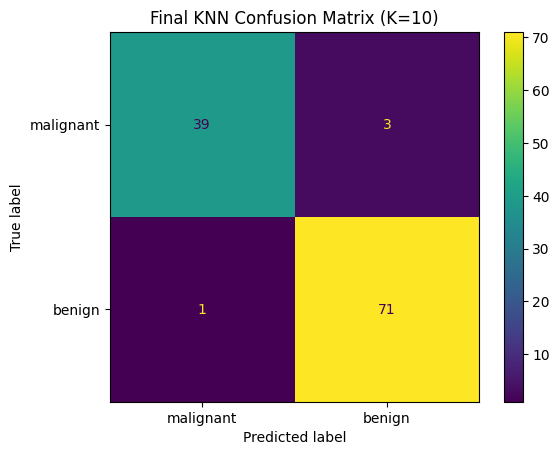

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    display_labels=data.target_names
)

plt.title("Final KNN Confusion Matrix (K=10)")
plt.show()

In [16]:
print("Final KNN Results (K=10)")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_auc)

Final KNN Results (K=10)
Accuracy : 0.9649122807017544
Precision: 0.9594594594594594
Recall   : 0.9861111111111112
F1 Score : 0.9726027397260274
ROC-AUC  : 0.9930555555555556
